# PAS-LGT — Phase 1 on Colab

Baseline Seq2Seq Transformer for long-term highway trajectory prediction.

**Before running:** switch the runtime to a GPU
(`Runtime -> Change runtime type -> T4 GPU`). Phase 1 also runs on CPU, just
slower.

The project lives in the `bunes/` subfolder of the shared course repo, which is
public -- so cloning needs no token or SSH key.

Nothing needs to be uploaded: the dataset is generated synthetically inside the
repo. Real NGSIM/highD data is handled in the last section.

## 1. Get the code

In [3]:
# HTTPS (not the git@ SSH remote) so Colab needs no key -- the repo is public.
REPO_URL = "https://github.com/sepanta-ghonoodi/Distributed-Computing.git"
BRANCH   = "main"
SUBDIR   = "bunes"   # the PAS-LGT project inside the shared course repo

import os, subprocess, sys
from pathlib import Path

REPO_DIR    = Path("/content") / Path(REPO_URL).stem
PROJECT_DIR = REPO_DIR / SUBDIR

def sh(cmd, cwd=None):
    """Run a shell command, streaming output, and fail loudly."""
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, cwd=cwd, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(r.stdout)
    if r.returncode != 0:
        raise RuntimeError(f"command failed ({r.returncode}): {cmd}")

if REPO_DIR.exists():
    # Re-running after new commits are pushed: fast-forward only, so a dirty or
    # diverged checkout fails visibly instead of silently merging. This is a
    # shared repo, so a teammate's push can legitimately cause that.
    sh(f"git fetch origin {BRANCH} && git checkout {BRANCH} && git pull --ff-only", cwd=REPO_DIR)
else:
    sh(f"git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}")

assert PROJECT_DIR.exists(), (
    f"{PROJECT_DIR} not found -- has the '{SUBDIR}/' folder been pushed yet?"
)

os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
print("\nworking directory:", os.getcwd())
sh("git log --oneline -1")

$ git fetch origin main && git checkout main && git pull --ff-only
From https://github.com/sepanta-ghonoodi/Distributed-Computing
 * branch            main       -> FETCH_HEAD
   8b3b3c1..66545ba  main       -> origin/main
Already on 'main'
Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating 8b3b3c1..66545ba
Fast-forward
 bunes/configs/ngsim_control.yaml   |  51 +++++++++
 bunes/configs/ngsim_idm.yaml       |  63 +++++++++++
 bunes/notebooks/colab_phase1.ipynb |  96 +++++++++++++++-
 bunes/scripts/download_ngsim.py    |  60 ++++++++++
 bunes/src/data/preprocess.py       | 220 ++++++++++++++++++++++++++++++-------
 bunes/tests/test_ngsim_parser.py   | 124 +++++++++++++++++++++
 6 files changed, 571 insertions(+), 43 deletions(-)
 create mode 100644 bunes/configs/ngsim_control.yaml
 create mode 100644 bunes/configs/ngsim_idm.yaml
 create mode 100644 bunes/scripts/download_ngsim.py
 create mode 100644 bunes/te

## 2. Environment check

In [21]:
# Colab already ships torch, numpy, pandas, scipy, pyarrow, yaml, tqdm,
# matplotlib and pytest -- Phase 1 needs no installs at all. This cell only
# reports what is present so a version surprise shows up here rather than 40
# minutes into a training run.
import importlib

import torch

print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device: {torch.cuda.get_device_name(0)}")
else:
    print("no GPU attached -- training falls back to CPU (Runtime > Change runtime type)")

for mod in ["numpy", "pandas", "scipy", "pyarrow", "yaml", "tqdm", "matplotlib", "pytest"]:
    try:
        m = importlib.import_module(mod)
        print(f"  OK   {mod:<12} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"  MISS {mod}   <-- run: !pip install {mod}")

torch 2.11.0+cu128 | CUDA available: True
device: Tesla T4
  OK   numpy        2.0.2
  OK   pandas       2.2.2
  OK   scipy        1.16.3
  OK   pyarrow      18.1.0
  OK   yaml         6.0.3
  OK   tqdm         4.67.3
  OK   matplotlib   3.10.0
  OK   pytest       8.4.2


In [ ]:
# Only needed from Phase 2 onwards (Link Projection / lane graph / VEC solver).
# Safe to run now; skip it while you are only on Phase 1.
# !pip install -q shapely scikit-learn networkx einops pulp

## 3. Smoke tests

Run these first. They check the agent-frame geometry, the window shapes, and the
teacher-forcing vs. autoregressive-rollout parity -- the invariant that otherwise
fails silently and produces a model that trains fine but predicts garbage.

In [28]:
!python -m pytest tests/ -q

.............                                                            [100%]
=============================== warnings summary ===============================
tests/test_smoke.py::test_teacher_forcing_matches_rollout
tests/test_smoke.py::test_untrained_model_is_constant_velocity
tests/test_smoke.py::test_rollout_does_not_integrate_its_own_error
tests/test_smoke.py::test_link_projection_snaps_to_lane_centres
tests/test_smoke.py::test_rollout_hook_is_applied
  /usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
    self.encoder = TransformerEncoder(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
13 passed, 5 warnings in 4.34s


## 4. Build the dataset

Synthetic multi-lane highway traffic with IDM car-following and lane changes,
resampled to 2 Hz. Roughly 15 seconds to generate.

In [14]:
!python scripts/make_dummy_data.py --vehicles 200 --lanes 4 --duration 900 --target-hz 2.0

simulating 200 vehicles x 900s on 4 lanes ...
wrote data/processed/unified.parquet | 360,000 rows, 200 vehicles, 2.0 Hz, mean speed 22.0 m/s


In [15]:
# Peek at what was produced.
import pandas as pd

df = pd.read_parquet("data/processed/unified.parquet")
print(df.shape, "|", df["vehicle_id"].nunique(), "vehicles")
display(df.head())
print(df[["speed", "accel", "lane_offset", "gap"]].describe().round(2))

(360000, 17) | 200 vehicles


,vehicle_id,frame,t,x,y,vx,vy,speed,accel,heading,lane_id,length,width,leader_id,gap,leader_speed,lane_offset
0,0,0,0.0,3.186885,-0.068346,24.056705,0.056178,24.056771,-0.209171,0.002335,0,4.764354,1.934476,1,28.598704,25.099422,-0.068280
1,0,1,0.5,15.215238,-0.040257,23.952131,0.050601,23.952185,-0.313753,0.002113,0,4.764354,1.934476,1,28.586842,25.013539,-0.040191
2,0,2,1.0,27.139017,-0.017745,23.742985,0.039446,23.743017,-0.418330,0.001661,0,4.764354,1.934476,1,29.029106,24.841779,-0.017679
3,0,3,1.5,38.958222,-0.000811,23.533838,0.028291,23.533855,-0.464913,0.001202,0,4.764354,1.934476,1,29.682429,24.670026,-0.000745
4,0,4,2.0,50.672855,0.010546,23.278101,0.011516,23.278104,-0.464937,0.000495,0,4.764354,1.934476,1,30.403669,24.563369,0.010612


           speed      accel  lane_offset        gap
count  360000.00  360000.00    360000.00  360000.00
mean       22.01      -0.00        -0.00      44.34
std         1.27       0.20         0.16      12.37
min         2.82      -6.31        -3.55     -12.53
25%        21.41      -0.03        -0.01      38.83
50%        22.04       0.00         0.00      41.63
75%        22.67       0.04         0.01      45.69
max        35.66       1.64         3.52     355.11


## 5. Train

About 8-15 minutes on a T4 for 60 epochs at this size. The constant-velocity
baseline is printed first -- the model must beat it, or something is wrong.

In [16]:
!python -m src.train --config configs/phase1_colab.yaml

windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 001 | train 1.780 | val ADE 17.07 m  FDE 38.36 m | lat 1.88  long 25.60  <-- WORSE THAN CONSTANT VELOCITY
epoch 002 | train 0.511 | val ADE 8.73 m  FDE 25.74 m | lat 1.72  long 17.48  <-- WORSE THAN CONSTANT VELOCITY
epoch 003 | train 0.367 | val ADE 10.76 m  FDE 35.94 m | lat 1.45  long 18.48  <-- WORSE THAN CONSTANT VELOCITY
epoch 004 | train 0.275 | val ADE 10.54 m  FDE 25.45 m | lat 0.98  long 16.76  <-- WORSE THAN CONSTANT VELOCITY
epoch 005 | train 0.211 | val ADE 26.74 m  FDE 77.42 m | lat 1.16  long 40.05  <-- WORSE THAN CONSTANT VELOCITY
epoch 006 | train 0.175 | val ADE 7

## 6. Evaluate

Autoregressive rollout on the held-out test vehicles, next to the
constant-velocity reference, with the longitudinal/lateral error split.

In [17]:
!python -m src.evaluate --ckpt runs/phase1_colab/best.pt --split test --plot

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(

=== test set (12,930 windows) ===
metric             PAS-LGT (Phase 1)    const-velocity
ade                            5.195             7.776
ade@10s                        0.514             1.294
ade@1s                         0.031             0.042
ade@20s                        2.405             4.130
ade@30s                        5.195             7.776
ade@3s                         0.063             0.180
ade@5s                         0.135             0.403
fde                           14.172            19.166
fde@10s                        1.552             3.351
fde@1s                         0.034             0.062
fde@20s                        7.158            10.615
fde@30s                       14.172            19.166
fde@3s         

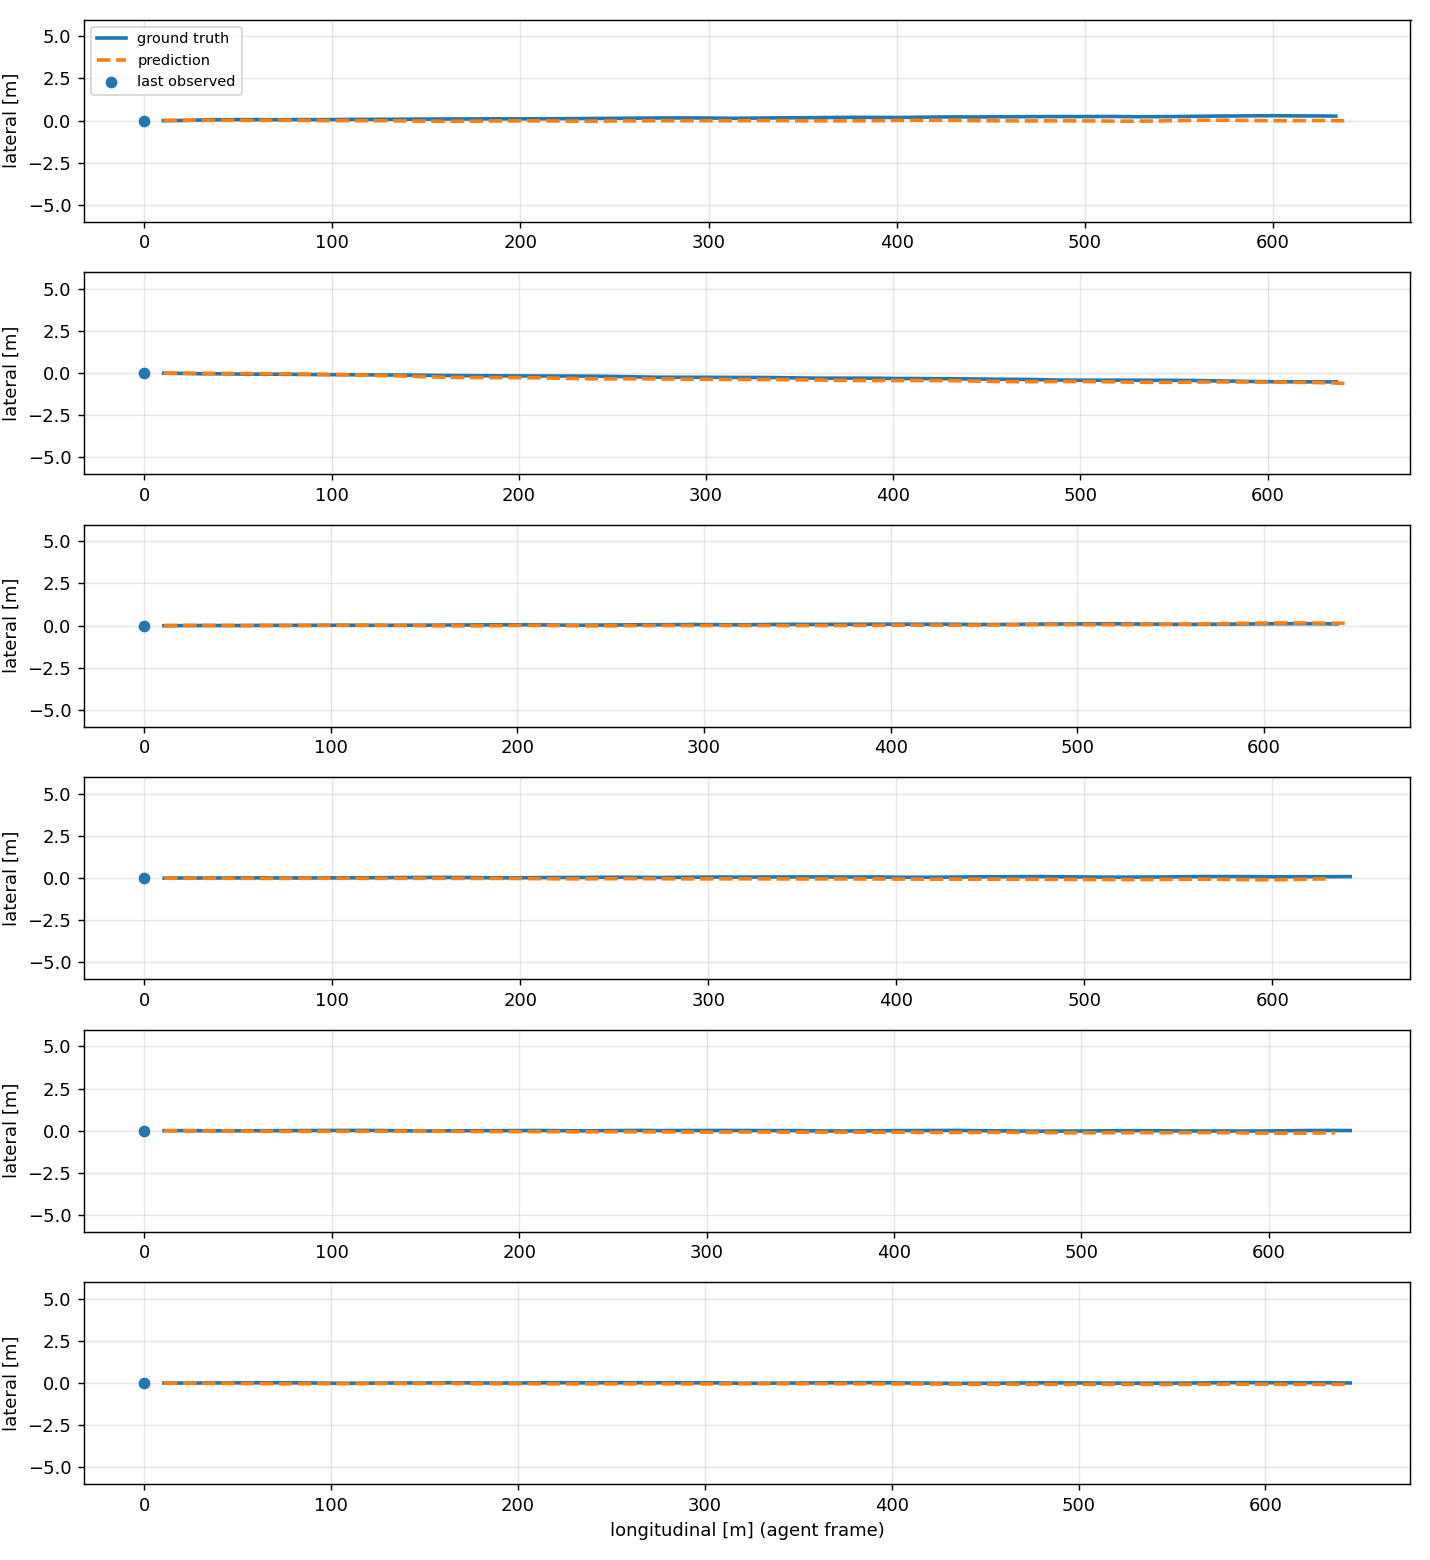

In [18]:
from IPython.display import Image, display

display(Image("runs/phase1_colab/examples_test.png"))

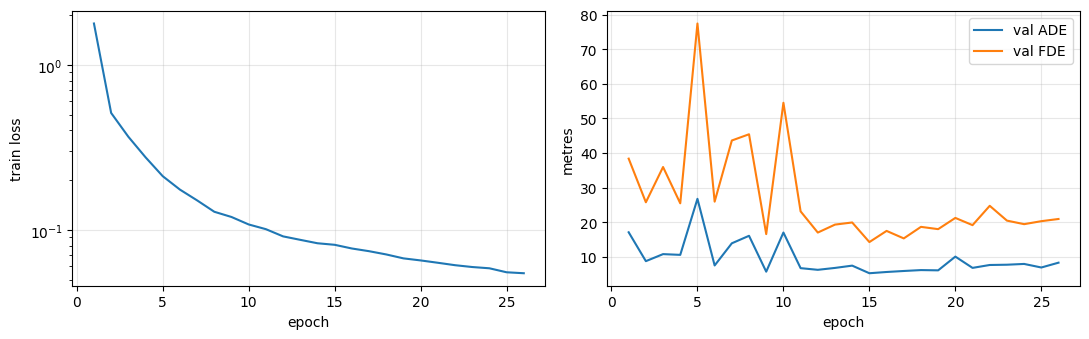

In [19]:
# Training curve.
import json

import matplotlib.pyplot as plt

hist = json.load(open("runs/phase1_colab/history.json"))
ep = [h["epoch"] for h in hist]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ep, [h["train_loss"] for h in hist])
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_yscale("log")
ax[0].grid(alpha=0.3)

ax[1].plot(ep, [h.get("val_ade") for h in hist], label="val ADE")
ax[1].plot(ep, [h.get("val_fde") for h in hist], label="val FDE")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("metres"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()

## 7. Keeping results

Colab wipes `/content` when the runtime disconnects. To keep a checkpoint, copy
it to Drive:

```python
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/pas-lgt-runs && cp -r runs/phase1_colab /content/drive/MyDrive/pas-lgt-runs/
```

## 8. Real data (NGSIM / highD)

Upload the raw files to Drive once, then point the preprocessor at them. This
writes the same `unified.parquet`, so every cell above works unchanged.

```python
from google.colab import drive
drive.mount('/content/drive')

# NGSIM: a single trajectory CSV
!python -m src.data.preprocess --source ngsim \
    --raw /content/drive/MyDrive/data/ngsim_us101.csv --target-hz 2.0

# highD: the directory containing *_tracks.csv and *_tracksMeta.csv
!python -m src.data.preprocess --source highd \
    --raw /content/drive/MyDrive/data/highd --target-hz 2.0
```

Then re-run training with `--no-cache` so the window cache is rebuilt from the
new parquet rather than reused from the synthetic run:

```python
!python -m src.train --config configs/phase1_colab.yaml --no-cache
```

## 9. Picking up new commits

After a new commit is pushed, re-run cell 1 -- it fast-forwards the checkout --
then re-run whichever cells you need. No re-upload, no re-setup.

Because this is the shared course repo, `git pull --ff-only` will refuse rather
than merge if the branch has diverged. That is deliberate: it surfaces the
conflict here instead of quietly training on a mixed tree.

In [23]:
!python -m src.ablation --ckpt runs/phase1_colab/best.pt --split test --plot

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
lane map | 4 centrelines at [-0.0, 3.7, 7.4, 11.1] m, mean spacing 3.70 m


=== test set (12,930 windows) ===
model                        ade          fde      ade@10s      ade@30s    rmse_long     rmse_lat miss_rate@5m     off_road
---------------------------------------------------------------------------------------------------------------------------
Phase 1 (no snap)          5.195       14.172        0.514        5.195       10.206        0.684        0.748        0.001
+ LinkProj b=0.5           5.198       14.225        0.508        5.198       10.209        0.579        0.749        0.000
+ LinkProj b=1             5.207       14.280        0.507        5.207       10.238        0.544        0.750        0.000
constant velocity          7.776   

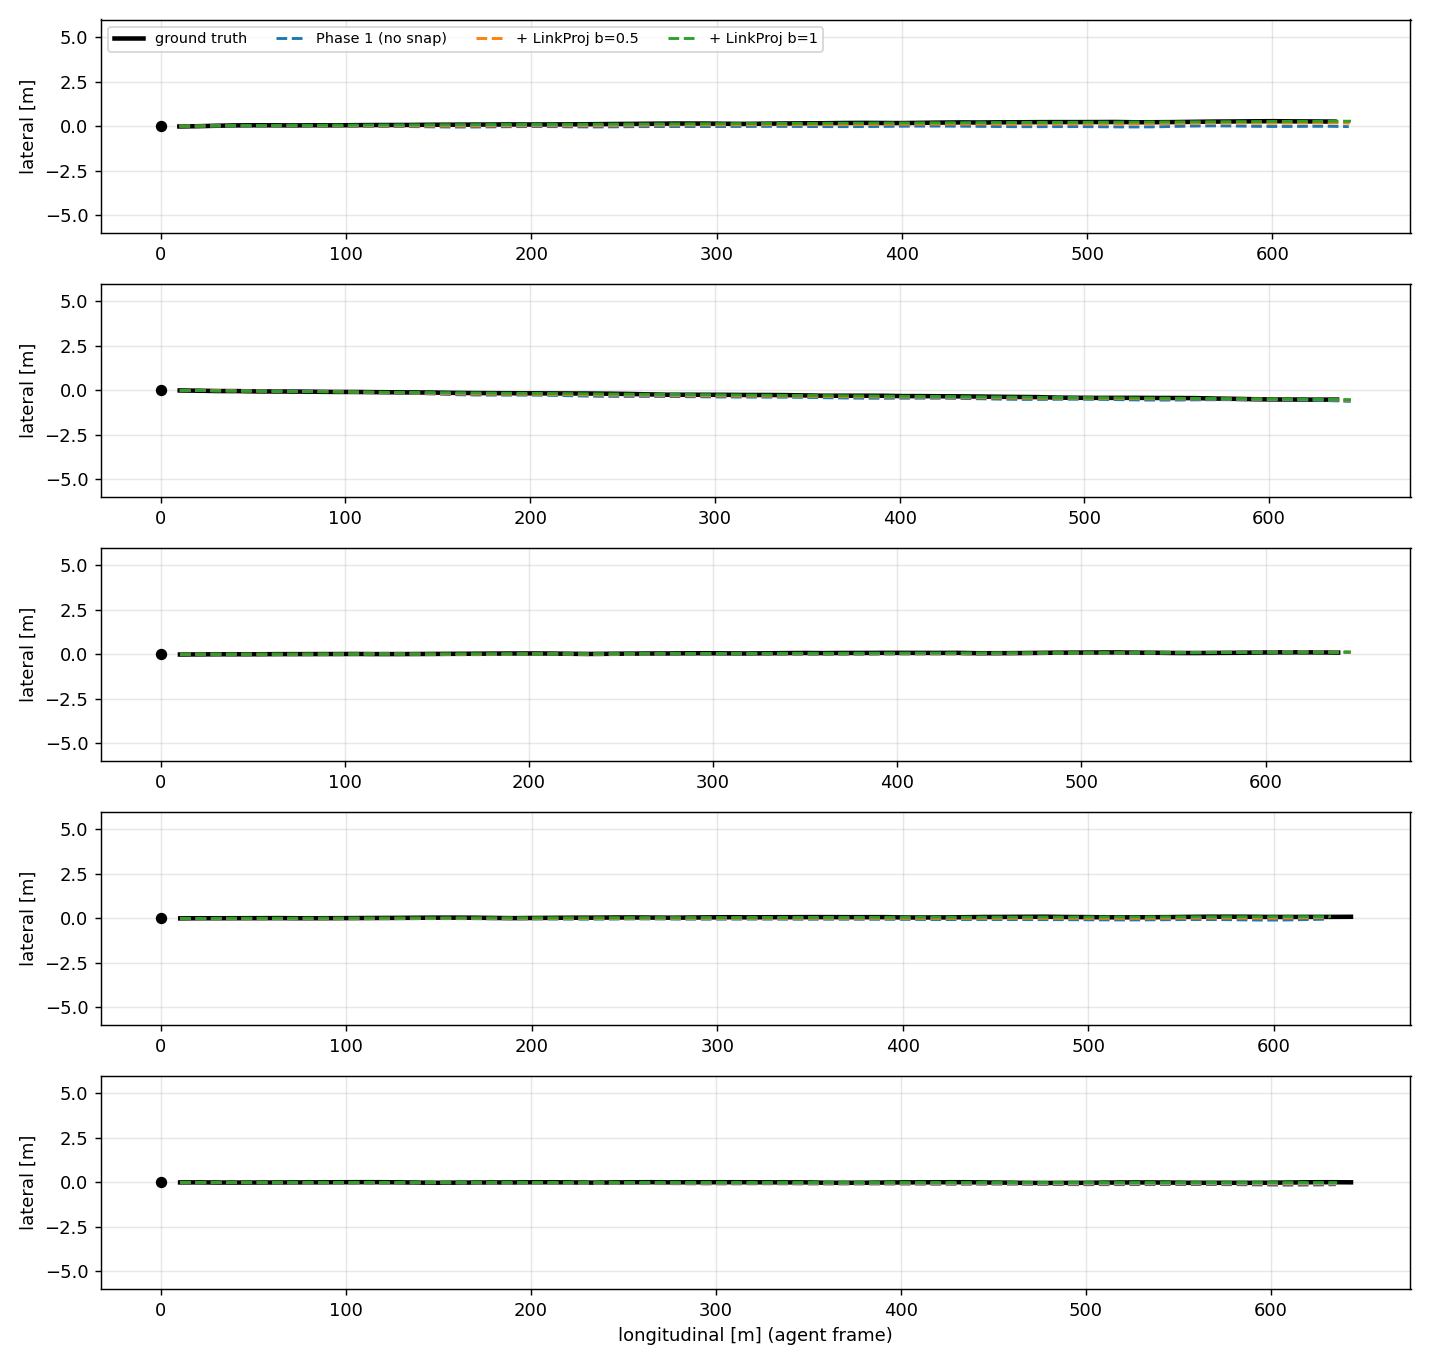

In [24]:
from IPython.display import Image, display
display(Image("runs/phase1_colab/ablation_test.png"))

In [29]:
!python -m src.train --config configs/phase12_short.yaml

windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 002 | train 0.489 | val ADE 6.20 m  FDE 16.49 m | lat 1.67  long 12.17
epoch 004 | train 0.270 | val ADE 12.16 m  FDE 36.89 m | lat 1.22  long 19.79  <-- WORSE THAN CONSTANT VELOCITY
epoch 006 | train 0.181 | val ADE 6.58 m  FDE 20.26 m | lat 0.77  long 12.02
epoch 008 | train 0.136 | val ADE 5.93 m  FDE 18.40 m | lat 0.94  long 12.31
epoch 010 | train 0.107 | val ADE 8.62 m  FDE 24.19 m | lat 0.76  long 15.24  <-- WORSE THAN CONSTANT VELOCITY
epoch 012 | train 0.091 | val ADE 5.45 m  FDE 15.93 m | lat 0.83  long 10.53
epoch 014 | train 0.080 | val ADE 5.11 m  FDE 14.71 m | lat 0.7

In [4]:
!python -m src.train --config configs/phase3_idm.yaml

windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 001 [train]:   0% 0/471 [00:00<?, ?it/s]/content/Distributed-Computing/bunes/src/engine.py:138: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running_phy += float(phy_loss) * bs
epoch 002 | train 1.756 (data 1.064 + IDM 2.305) | val ADE 5.66 m  FDE 14.59 m | lat 1.76  long 11.55
epoch 004 | train 1.446 (data 0.807 + IDM 2.130) | val ADE 6.05 m  FDE 15.69 m | lat 1.41  long 12.06
epoch 006 | 

In [5]:
!python -m src.ablation --ckpt runs/p12_short/best.pt --split test --blends 0.0 1.0

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
lane map | 4 centrelines at [-0.0, 3.7, 7.4, 11.1] m, mean spacing 3.70 m


=== test set (12,930 windows) ===
model                        ade          fde      ade@10s      ade@30s    rmse_long     rmse_lat miss_rate@5m     off_road
---------------------------------------------------------------------------------------------------------------------------
Phase 1 (no snap)          4.983       14.551        0.454        4.983        9.944        0.542        0.732        0.000
+ LinkProj b=1             4.992       14.606        0.451        4.992        9.968        0.514        0.733        0.000
constant velocity          7.776       19.166        1.294        7.776       15.105        1.513        0.781          nan

wrote runs/p12_short/ablation_test

In [12]:
!python -m src.ablation --ckpt runs/p3_idm/best.pt --split test --blends 0.0 1.0 --plot

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
lane map | 4 centrelines at [-0.0, 3.7, 7.4, 11.1] m, mean spacing 3.70 m


=== test set (12,930 windows) ===
model                        ade          fde      ade@10s      ade@30s    rmse_long     rmse_lat miss_rate@5m     off_road
---------------------------------------------------------------------------------------------------------------------------
Phase 1 (no snap)          5.626       14.657        0.805        5.626       12.011        1.404        0.697        0.004
+ LinkProj b=1             5.581       14.572        0.788        5.581       12.025        0.614        0.696        0.000
constant velocity          7.776       19.166        1.294        7.776       15.105        1.513        0.781          nan

wrote runs/p3_idm/ablation_test.js

In [7]:
!python scripts/download_ngsim.py --out data/raw/ngsim_all.csv

downloading NGSIM -> data/raw/ngsim_all.csv
  33 MBTraceback (most recent call last):
  File "/content/Distributed-Computing/bunes/scripts/download_ngsim.py", line 60, in <module>
    main()
  File "/content/Distributed-Computing/bunes/scripts/download_ngsim.py", line 54, in main
    urllib.request.urlretrieve(args.url, tmp, reporthook=_progress)
  File "/usr/lib/python3.12/urllib/request.py", line 268, in urlretrieve
    while block := fp.read(bs):
                   ^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 478, in read
    return self._read_chunked(amt)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 604, in _read_chunked
    value.append(self._safe_read(amt))
                 ^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 648, in _safe_read
    data = self.fp.read(cursize)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
 

In [8]:
!python -m src.data.preprocess --source ngsim --raw data/raw/ngsim_all.csv --target-hz 2.0 --max-vehicles 4000 --out data/processed/ngsim.parquet

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Distributed-Computing/bunes/src/data/preprocess.py", line 362, in <module>
    main()
  File "/content/Distributed-Computing/bunes/src/data/preprocess.py", line 345, in main
    df = build_unified(
         ^^^^^^^^^^^^^^
  File "/content/Distributed-Computing/bunes/src/data/preprocess.py", line 301, in build_unified
    df, source_hz = load_ngsim(raw, locations=locations, max_lane=max_lane), 10.0
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Distributed-Computing/bunes/src/data/preprocess.py", line 84, in load_ngsim
    header = pd.read_csv(path, nrows=0)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

In [9]:
# @title
!python -m src.train --config configs/ngsim_control.yamlTo undo cell deletion use Ctrl+M Z or the Undo option in the Edit menu
￼
close
Skip to main content
￼colab_phase1.ipynb_
￼
cloud_off
Save in GitHub to keep changes
File
Edit
View
Insert
Runtime
Tools
Help
￼
settings
￼
link
Share
￼
￼
search
CommandsShow command palette Ctrl+Shift+P
￼
add
CodeInsert code cell below Ctrl+M B
￼
arrow_drop_down
￼
add
TextAdd text cell
￼
play_arrow
Run allRun all cells in notebook
￼
arrow_drop_down
￼
Copy to Drive
￼
more_horiz
￼
RAM
Disk
Waiting to finish the current execution. Python 3 Google Compute Engine backend (GPU) RAM: 3.11 GB/12.67 GB Disk: 47.04 GB/112.64 GB
￼
arrow_drop_down
￼
expand_less
￼
format_list_bulleted
￼
find_in_page
￼
code
￼
eye_tracking
￼
vpn_key
￼
folder
￼
table
Table of contents
￼
tab
￼
close
PAS-LGT — Phase 1 on Colab
￼
play_arrow
￼
more_vert
Get the code
￼
play_arrow
￼
more_vert
Environment check
￼
play_arrow
￼
more_vert
Smoke tests
￼
play_arrow
￼
more_vert
Build the dataset
￼
play_arrow
￼
more_vert
Train
￼
play_arrow
￼
more_vert
Evaluate
￼
play_arrow
￼
more_vert
Keeping results
￼
more_vert
Real data (NGSIM / highD)
￼
more_vert
Picking up new commits
￼
play_arrow
￼
more_vert
￼
add
Section
￼
keyboard_arrow_down
PAS-LGT — Phase 1 on Colab
Baseline Seq2Seq Transformer for long-term highway trajectory prediction.

Before running: switch the runtime to a GPU (Runtime -> Change runtime type -> T4 GPU). Phase 1 also runs on CPU, just slower.

The project lives in the bunes/ subfolder of the shared course repo, which is public -- so cloning needs no token or SSH key.

Nothing needs to be uploaded: the dataset is generated synthetically inside the repo. Real NGSIM/highD data is handled in the last section.

￼
keyboard_arrow_down
1. Get the code
￼
[3]
check
0s
# HTTPS (not the git@ SSH remote) so Colab needs no key -- the repo is public.
REPO_URL = "https://github.com/sepanta-ghonoodi/Distributed-Computing.git"
BRANCH   = "main"
SUBDIR   = "bunes"   # the PAS-LGT project inside the shared course repo

import os, subprocess, sys
from pathlib import Path

REPO_DIR    = Path("/content") / Path(REPO_URL).stem
PROJECT_DIR = REPO_DIR / SUBDIR

def sh(cmd, cwd=None):
    """Run a shell command, streaming output, and fail loudly."""
    print(f"$ {cmd}")
    r = subprocess.run(cmd, shell=True, cwd=cwd, text=True,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(r.stdout)
    if r.returncode != 0:
        raise RuntimeError(f"command failed ({r.returncode}): {cmd}")

if REPO_DIR.exists():
    # Re-running after new commits are pushed: fast-forward only, so a dirty or
    # diverged checkout fails visibly instead of silently merging. This is a
    # shared repo, so a teammate's push can legitimately cause that.
    sh(f"git fetch origin {BRANCH} && git checkout {BRANCH} && git pull --ff-only", cwd=REPO_DIR)
else:
    sh(f"git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}")

assert PROJECT_DIR.exists(), (
    f"{PROJECT_DIR} not found -- has the '{SUBDIR}/' folder been pushed yet?"
)

os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
print("\nworking directory:", os.getcwd())
sh("git log --oneline -1")
￼
keyboard_arrow_down
￼
more_horiz
$ git fetch origin main && git checkout main && git pull --ff-only
From https://github.com/sepanta-ghonoodi/Distributed-Computing
 * branch            main       -> FETCH_HEAD
   8b3b3c1..66545ba  main       -> origin/main
Already on 'main'
Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
Updating 8b3b3c1..66545ba
Fast-forward
 bunes/configs/ngsim_control.yaml   |  51 +++++++++
 bunes/configs/ngsim_idm.yaml       |  63 +++++++++++
 bunes/notebooks/colab_phase1.ipynb |  96 +++++++++++++++-
 bunes/scripts/download_ngsim.py    |  60 ++++++++++
 bunes/src/data/preprocess.py       | 220 ++++++++++++++++++++++++++++++-------
 bunes/tests/test_ngsim_parser.py   | 124 +++++++++++++++++++++
 6 files changed, 571 insertions(+), 43 deletions(-)
 create mode 100644 bunes/configs/ngsim_control.yaml
 create mode 100644 bunes/configs/ngsim_idm.yaml
 create mode 100644 bunes/scripts/download_ngsim.py
 create mode 100644 bunes/tests/test_ngsim_parser.py


working directory: /content/Distributed-Computing/bunes
$ git log --oneline -1
66545ba Harden the NGSIM parser and wire up the real-data run

￼
keyboard_arrow_down
2. Environment check
￼
[ ]
# Colab already ships torch, numpy, pandas, scipy, pyarrow, yaml, tqdm,
# matplotlib and pytest -- Phase 1 needs no installs at all. This cell only
# reports what is present so a version surprise shows up here rather than 40
# minutes into a training run.
import importlib

import torch

print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device: {torch.cuda.get_device_name(0)}")
else:
    print("no GPU attached -- training falls back to CPU (Runtime > Change runtime type)")

for mod in ["numpy", "pandas", "scipy", "pyarrow", "yaml", "tqdm", "matplotlib", "pytest"]:
    try:
        m = importlib.import_module(mod)
        print(f"  OK   {mod:<12} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"  MISS {mod}   <-- run: !pip install {mod}")
￼
keyboard_arrow_down
￼
more_horiz
torch 2.11.0+cu128 | CUDA available: True
device: Tesla T4
  OK   numpy        2.0.2
  OK   pandas       2.2.2
  OK   scipy        1.16.3
  OK   pyarrow      18.1.0
  OK   yaml         6.0.3
  OK   tqdm         4.67.3
  OK   matplotlib   3.10.0
  OK   pytest       8.4.2
￼
[ ]
# Only needed from Phase 2 onwards (Link Projection / lane graph / VEC solver).
# Safe to run now; skip it while you are only on Phase 1.
# !pip install -q shapely scikit-learn networkx einops pulp
￼
keyboard_arrow_down
3. Smoke tests
Run these first. They check the agent-frame geometry, the window shapes, and the teacher-forcing vs. autoregressive-rollout parity -- the invariant that otherwise fails silently and produces a model that trains fine but predicts garbage.

￼
[ ]
!python -m pytest tests/ -q
￼
keyboard_arrow_down
￼
more_horiz
.............                                                            [100%]
=============================== warnings summary ===============================
tests/test_smoke.py::test_teacher_forcing_matches_rollout
tests/test_smoke.py::test_untrained_model_is_constant_velocity
tests/test_smoke.py::test_rollout_does_not_integrate_its_own_error
tests/test_smoke.py::test_link_projection_snaps_to_lane_centres
tests/test_smoke.py::test_rollout_hook_is_applied
  /usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
    self.encoder = TransformerEncoder(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
13 passed, 5 warnings in 4.34s
￼
keyboard_arrow_down
4. Build the dataset
Synthetic multi-lane highway traffic with IDM car-following and lane changes, resampled to 2 Hz. Roughly 15 seconds to generate.

￼
[ ]
!python scripts/make_dummy_data.py --vehicles 200 --lanes 4 --duration 900 --target-hz 2.0
￼
keyboard_arrow_down
￼
more_horiz
simulating 200 vehicles x 900s on 4 lanes ...
wrote data/processed/unified.parquet | 360,000 rows, 200 vehicles, 2.0 Hz, mean speed 22.0 m/s
￼
[ ]
# Peek at what was produced.
import pandas as pd

df = pd.read_parquet("data/processed/unified.parquet")
print(df.shape, "|", df["vehicle_id"].nunique(), "vehicles")
display(df.head())
print(df[["speed", "accel", "lane_offset", "gap"]].describe().round(2))
￼
keyboard_arrow_down
￼
more_horiz
￼
￼
keyboard_arrow_down
5. Train
About 8-15 minutes on a T4 for 60 epochs at this size. The constant-velocity baseline is printed first -- the model must beat it, or something is wrong.

￼
[ ]
!python -m src.train --config configs/phase1_colab.yaml
￼
keyboard_arrow_down
￼
more_horiz
windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 001 | train 1.780 | val ADE 17.07 m  FDE 38.36 m | lat 1.88  long 25.60  <-- WORSE THAN CONSTANT VELOCITY
epoch 002 | train 0.511 | val ADE 8.73 m  FDE 25.74 m | lat 1.72  long 17.48  <-- WORSE THAN CONSTANT VELOCITY
epoch 003 | train 0.367 | val ADE 10.76 m  FDE 35.94 m | lat 1.45  long 18.48  <-- WORSE THAN CONSTANT VELOCITY
epoch 004 | train 0.275 | val ADE 10.54 m  FDE 25.45 m | lat 0.98  long 16.76  <-- WORSE THAN CONSTANT VELOCITY
epoch 005 | train 0.211 | val ADE 26.74 m  FDE 77.42 m | lat 1.16  long 40.05  <-- WORSE THAN CONSTANT VELOCITY
epoch 006 | train 0.175 | val ADE 7.48 m  FDE 25.92 m | lat 0.99  long 14.26
epoch 007 | train 0.151 | val ADE 13.89 m  FDE 43.60 m | lat 0.85  long 21.88  <-- WORSE THAN CONSTANT VELOCITY
epoch 008 | train 0.129 | val ADE 16.06 m  FDE 45.40 m | lat 0.84  long 26.27  <-- WORSE THAN CONSTANT VELOCITY
epoch 009 | train 0.120 | val ADE 5.69 m  FDE 16.55 m | lat 0.75  long 10.48
epoch 010 | train 0.108 | val ADE 17.00 m  FDE 54.50 m | lat 1.13  long 30.51  <-- WORSE THAN CONSTANT VELOCITY
epoch 011 | train 0.101 | val ADE 6.71 m  FDE 23.12 m | lat 0.76  long 16.18
epoch 012 | train 0.091 | val ADE 6.22 m  FDE 16.99 m | lat 0.77  long 11.72
epoch 013 | train 0.087 | val ADE 6.77 m  FDE 19.29 m | lat 0.76  long 13.30
epoch 014 | train 0.083 | val ADE 7.43 m  FDE 19.91 m | lat 0.73  long 13.36
epoch 015 | train 0.081 | val ADE 5.24 m  FDE 14.24 m | lat 0.89  long 10.27
epoch 016 | train 0.077 | val ADE 5.60 m  FDE 17.47 m | lat 1.11  long 13.80
epoch 017 | train 0.074 | val ADE 5.89 m  FDE 15.30 m | lat 0.76  long 11.12
epoch 018 | train 0.071 | val ADE 6.15 m  FDE 18.64 m | lat 0.77  long 12.12
epoch 019 | train 0.067 | val ADE 6.07 m  FDE 17.98 m | lat 0.81  long 12.32
epoch 020 | train 0.065 | val ADE 10.04 m  FDE 21.23 m | lat 0.70  long 15.98  <-- WORSE THAN CONSTANT VELOCITY
epoch 021 | train 0.063 | val ADE 6.78 m  FDE 19.14 m | lat 0.95  long 14.19
epoch 022 | train 0.061 | val ADE 7.62 m  FDE 24.72 m | lat 0.81  long 14.18
epoch 023 | train 0.060 | val ADE 7.70 m  FDE 20.45 m | lat 0.73  long 13.90
epoch 024 | train 0.058 | val ADE 7.92 m  FDE 19.42 m | lat 0.72  long 13.97  <-- WORSE THAN CONSTANT VELOCITY
epoch 025 | train 0.055 | val ADE 6.89 m  FDE 20.28 m | lat 0.71  long 12.78
epoch 026 | train 0.055 | val ADE 8.29 m  FDE 20.92 m | lat 0.79  long 14.50  <-- WORSE THAN CONSTANT VELOCITY
epoch 027 | train 0.053 | val ADE 8.60 m  FDE 19.42 m | lat 0.76  long 14.19  <-- WORSE THAN CONSTANT VELOCITY
early stopping at epoch 27 (best val ADE 5.24 m)
done | best val ADE 5.24 m | checkpoint runs/phase1_colab/best.pt
￼
keyboard_arrow_down
6. Evaluate
Autoregressive rollout on the held-out test vehicles, next to the constant-velocity reference, with the longitudinal/lateral error split.

￼
[ ]
!python -m src.evaluate --ckpt runs/phase1_colab/best.pt --split test --plot
￼
keyboard_arrow_down
￼
more_horiz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(

=== test set (12,930 windows) ===
metric             PAS-LGT (Phase 1)    const-velocity
ade                            5.195             7.776
ade@10s                        0.514             1.294
ade@1s                         0.031             0.042
ade@20s                        2.405             4.130
ade@30s                        5.195             7.776
ade@3s                         0.063             0.180
ade@5s                         0.135             0.403
fde                           14.172            19.166
fde@10s                        1.552             3.351
fde@1s                         0.034             0.062
fde@20s                        7.158            10.615
fde@30s                       14.172            19.166
fde@3s                         0.114             0.393
fde@5s                         0.337             0.976
miss_rate@5m                   0.748             0.781
rmse_lat                       0.684             1.513
rmse_long                     10.206            15.105
wrote runs/phase1_colab/examples_test.png
￼
[ ]
from IPython.display import Image, display

display(Image("runs/phase1_colab/examples_test.png"))
￼
keyboard_arrow_down
￼
more_horiz
￼
￼
[ ]
# Training curve.
import json

import matplotlib.pyplot as plt

hist = json.load(open("runs/phase1_colab/history.json"))
ep = [h["epoch"] for h in hist]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ep, [h["train_loss"] for h in hist])
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].set_yscale("log")
ax[0].grid(alpha=0.3)

ax[1].plot(ep, [h.get("val_ade") for h in hist], label="val ADE")
ax[1].plot(ep, [h.get("val_fde") for h in hist], label="val FDE")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("metres"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
￼
keyboard_arrow_down
￼
more_horiz
￼
7. Keeping results
Colab wipes /content when the runtime disconnects. To keep a checkpoint, copy it to Drive:

from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/pas-lgt-runs && cp -r runs/phase1_colab /content/drive/MyDrive/pas-lgt-runs/
8. Real data (NGSIM / highD)
Upload the raw files to Drive once, then point the preprocessor at them. This writes the same unified.parquet, so every cell above works unchanged.

from google.colab import drive
drive.mount('/content/drive')

# NGSIM: a single trajectory CSV
!python -m src.data.preprocess --source ngsim \
    --raw /content/drive/MyDrive/data/ngsim_us101.csv --target-hz 2.0

# highD: the directory containing *_tracks.csv and *_tracksMeta.csv
!python -m src.data.preprocess --source highd \
    --raw /content/drive/MyDrive/data/highd --target-hz 2.0
Then re-run training with --no-cache so the window cache is rebuilt from the new parquet rather than reused from the synthetic run:

!python -m src.train --config configs/phase1_colab.yaml --no-cache
￼
keyboard_arrow_down
9. Picking up new commits
After a new commit is pushed, re-run cell 1 -- it fast-forwards the checkout -- then re-run whichever cells you need. No re-upload, no re-setup.

Because this is the shared course repo, git pull --ff-only will refuse rather than merge if the branch has diverged. That is deliberate: it surfaces the conflict here instead of quietly training on a mixed tree.

￼
[ ]
!python -m src.ablation --ckpt runs/phase1_colab/best.pt --split test --plot
￼
keyboard_arrow_down
￼
more_horiz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
lane map | 4 centrelines at [-0.0, 3.7, 7.4, 11.1] m, mean spacing 3.70 m


=== test set (12,930 windows) ===
model                        ade          fde      ade@10s      ade@30s    rmse_long     rmse_lat miss_rate@5m     off_road
---------------------------------------------------------------------------------------------------------------------------
Phase 1 (no snap)          5.195       14.172        0.514        5.195       10.206        0.684        0.748        0.001
+ LinkProj b=0.5           5.198       14.225        0.508        5.198       10.209        0.579        0.749        0.000
+ LinkProj b=1             5.207       14.280        0.507        5.207       10.238        0.544        0.750        0.000
constant velocity          7.776       19.166        1.294        7.776       15.105        1.513        0.781          nan

wrote runs/phase1_colab/ablation_test.json
wrote runs/phase1_colab/ablation_test.png
￼
[ ]
from IPython.display import Image, display
display(Image("runs/phase1_colab/ablation_test.png"))
￼
keyboard_arrow_down
￼
more_horiz
￼
￼
[ ]
!python -m src.train --config configs/phase12_short.yaml
￼
￼
keyboard_arrow_down
￼
more_horiz
windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 002 | train 0.489 | val ADE 6.20 m  FDE 16.49 m | lat 1.67  long 12.17
epoch 004 | train 0.270 | val ADE 12.16 m  FDE 36.89 m | lat 1.22  long 19.79  <-- WORSE THAN CONSTANT VELOCITY
epoch 006 | train 0.181 | val ADE 6.58 m  FDE 20.26 m | lat 0.77  long 12.02
epoch 008 | train 0.136 | val ADE 5.93 m  FDE 18.40 m | lat 0.94  long 12.31
epoch 010 | train 0.107 | val ADE 8.62 m  FDE 24.19 m | lat 0.76  long 15.24  <-- WORSE THAN CONSTANT VELOCITY
epoch 012 | train 0.091 | val ADE 5.45 m  FDE 15.93 m | lat 0.83  long 10.53
epoch 014 | train 0.080 | val ADE 5.11 m  FDE 14.71 m | lat 0.71  long 10.21
epoch 016 | train 0.074 | val ADE 5.83 m  FDE 16.23 m | lat 0.72  long 10.72
epoch 018 | train 0.071 | val ADE 6.24 m  FDE 17.78 m | lat 0.71  long 11.53
epoch 020 | train 0.070 | val ADE 5.79 m  FDE 16.57 m | lat 0.70  long 10.92
done | best val ADE 5.11 m | checkpoint runs/p12_short/best.pt
￼
[4]
!python -m src.train --config configs/phase3_idm.yaml
￼
keyboard_arrow_down
￼
more_horiz
windows | train 60,340 val 12,930 test 12,930 | obs 20 steps, pred 60 steps @ 2.0 Hz
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(
model  | 1.86M trainable parameters
const-velocity baseline | ADE 7.89 m  FDE 19.30 m
epoch 001 [train]:   0% 0/471 [00:00<?, ?it/s]/content/Distributed-Computing/bunes/src/engine.py:138: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running_phy += float(phy_loss) * bs
epoch 002 | train 1.756 (data 1.064 + IDM 2.305) | val ADE 5.66 m  FDE 14.59 m | lat 1.76  long 11.55
[val]:  27% 14/51 [00:11<00:31,  1.19it/s]￼
￼
[ ]
!python -m src.ablation --ckpt runs/p12_short/best.pt --split test --blends 0.0 1.0
￼
arrow_upward
￼
arrow_downward
￼
pen_spark
￼
delete
￼
more_vert
￼
[ ]
!python -m src.ablation --ckpt runs/p3_idm/best.pt --split test --blends 0.0 1.0 --plot
￼
￼
[ ]
!python scripts/download_ngsim.py --out data/raw/ngsim_all.csv
￼
[ ]
!python -m src.data.preprocess --source ngsim --raw data/raw/ngsim_all.csv --target-hz 2.0 --max-vehicles 4000 --out data/processed/ngsim.parquet
￼
[ ]
!python -m src.train --config configs/ngsim_control.yaml
￼
[ ]
!python -m src.train --config configs/ngsim_idm.yaml
￼
[ ]
!python -m src.ablation --ckpt runs/ngsim_idm/best.pt --split test --blends 0.0 1.0 --plot
￼
Colab paid products
-
Cancel contracts here
￼
spark
￼
data_object
Variables
￼
terminal
Terminal
￼
Executing (2m 38s)
￼
dns
T4 (Python 3)


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Distributed-Computing/bunes/src/train.py", line 157, in <module>
    main()
  File "/content/Distributed-Computing/bunes/src/train.py", line 59, in main
    datasets, scaler = load_splits(cfg.data, use_cache=not args.no_cache)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Distributed-Computing/bunes/src/data/dataset.py", line 288, in load_splits
    df = pd.read_parquet(cfg.unified_path)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 667, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 267, in read
    path_or_handle, handles, filesystem = _get_path_or_handle(
                                          ^^^^^^^^^^^^^^^^^^^^
  File "

In [10]:
!python -m src.train --config configs/ngsim_idm.yaml

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Distributed-Computing/bunes/src/train.py", line 157, in <module>
    main()
  File "/content/Distributed-Computing/bunes/src/train.py", line 59, in main
    datasets, scaler = load_splits(cfg.data, use_cache=not args.no_cache)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/Distributed-Computing/bunes/src/data/dataset.py", line 288, in load_splits
    df = pd.read_parquet(cfg.unified_path)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 667, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parquet.py", line 267, in read
    path_or_handle, handles, filesystem = _get_path_or_handle(
                                          ^^^^^^^^^^^^^^^^^^^^
  File "

In [11]:
!python -m src.ablation --ckpt runs/ngsim_idm/best.pt --split test --blends 0.0 1.0 --plot

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/Distributed-Computing/bunes/src/ablation.py", line 241, in <module>
    main()
  File "/content/Distributed-Computing/bunes/src/ablation.py", line 60, in main
    ckpt = torch.load(args.ckpt, map_location="cpu", weights_only=False)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1530, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 795, in _open_file_like
    return _open_file(name_or_buffer, mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 776, in __init__
    super().__init__(open(name, mode))  # noqa: SIM115
                     ^